## SUMMARY

Documentation:
    <https://mesonet.agron.iastate.edu/nws/cf6table.php?station=KNYC&opt=bystation&year=2024>

The API specifically calls:
    <https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024>

***

In [13]:
import dataset # local
import pandas as pd
import numpy as np
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
# Using new API
response = requests.get("https://mesonet.agron.iastate.edu/json/cf6.py?station=KNYC&year=2024").json()
wthr = pd.DataFrame(response['results'])
wthr['date'] = pd.to_datetime(wthr['valid'])
wthr = wthr.drop(columns=['name', 'station', 'valid', 'state', 'wfo', 'link', 'product', 'minutes_sunshine', 'possible_sunshine', 'hdd', 'cdd', 'gust_drct', 'avg_drct', 'snowd_12z', 'avg_smph'])

# CF6 Code	Abbrev	Meaning
# 1	FG	Fog or Mist
# 2	DNSEFG	Fog or Vis 0.25 mile or less
# 3	TS	Thunder
# 4	IP	Ice pellets
# 5	GR	Hail
# 6	FZRA	Freezing Rain or Drizzle
# 7	DSTSTM	Duststorm or Sandstorm vis 0.25 mile or less
# 8	HZ	Smoke or Haze
# 9	BLSN	Blowing Snow
# X	TOR	Tornado
# M	M	Missing Data
wthr['fog']           = wthr['wxcodes'].str.contains('1', na=False).astype(bool)
wthr['low_vis']       = wthr['wxcodes'].str.contains('2', na=False).astype(bool)
wthr['thunder']       = wthr['wxcodes'].str.contains('3', na=False).astype(bool)
wthr['ice']           = wthr['wxcodes'].str.contains('4', na=False).astype(bool)
wthr['hail']          = wthr['wxcodes'].str.contains('5', na=False).astype(bool)
wthr['freezing_rain'] = wthr['wxcodes'].str.contains('6', na=False).astype(bool)
wthr['duststorm']     = wthr['wxcodes'].str.contains('7', na=False).astype(bool)
wthr['haze']          = wthr['wxcodes'].str.contains('8', na=False).astype(bool)
wthr['blowing_snow']  = wthr['wxcodes'].str.contains('9', na=False).astype(bool)
wthr['tornado']       = wthr['wxcodes'].str.contains('X', na=False).astype(bool)

# A lot of numerical values can include 'T' as an entry
#
# This refers to 'trace amounts', i.e. miniscule levels of precipitation; we will just replace with 0
wthr.replace('T', 0, inplace=True)
wthr.replace('M', np.nan, inplace=True)
wthr = wthr.astype({
    'snow': 'float64',
    'precip': 'float64',
})

wthr = wthr.drop(columns=[
    'wxcodes', # redundant
    'ice', # empty
    'tornado', # empty
    'blowing_snow', # empty
    'duststorm', # empty
    'avg_temp', # using 'high'
    'dep_temp', # using 'high'
    'low', # using 'high'
])

wthr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   high           366 non-null    int64         
 1   precip         366 non-null    float64       
 2   snow           366 non-null    float64       
 3   max_smph       363 non-null    float64       
 4   cloud_ss       366 non-null    float64       
 5   gust_smph      360 non-null    float64       
 6   date           366 non-null    datetime64[ns]
 7   fog            366 non-null    bool          
 8   low_vis        366 non-null    bool          
 9   thunder        366 non-null    bool          
 10  hail           366 non-null    bool          
 11  freezing_rain  366 non-null    bool          
 12  haze           366 non-null    bool          
dtypes: bool(6), datetime64[ns](1), float64(5), int64(1)
memory usage: 22.3 KB


<positron-console-cell-69>:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
<positron-console-cell-69>:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


# Read the taxi data in

In [3]:
df = dataset.read_agg(month_start=1, month_end=12)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2887842 entries, 0 to 2887841
Data columns (total 34 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   pickup_year            int32         
 1   pickup_month           int32         
 2   pickup_week            UInt32        
 3   pickup_day             int32         
 4   pickup_date            datetime64[ns]
 5   pickup_dow             int32         
 6   pickup_service_zone    category      
 7   pickup_zone            object        
 8   dropoff_service_zone   category      
 9   dropoff_zone           object        
 10  route                  object        
 11  service_route          category      
 12  vendor                 object        
 13  total_ride_count       int64         
 14  total_passenger_count  float64       
 15  avg_passenger_count    float64       
 16  total_trip_distance    float64       
 17  avg_trip_distance      float64       
 18  total_fare_amount     

# Aggregate to daily

In [28]:
daily = df[df['pickup_year'] == 2024].groupby(by=['pickup_date'], as_index=False).agg(
    total_ride_count  = ('total_ride_count','sum'),
    avg_ride_count    = ('total_ride_count', 'mean'),
)
daily = pd.merge(daily, wthr, left_on='pickup_date', right_on='date', how='left')
daily['log_ride_count'] = np.log(daily['total_ride_count'].replace(0, np.nan))
daily['log_precip'] = np.log(daily['precip'].replace(0, np.nan))
daily

,pickup_date,total_ride_count,avg_ride_count,high,low,avg_temp,dep_temp,precip,snow,max_smph,...,thunder,ice,hail,freezing_rain,duststorm,haze,blowing_snow,tornado,log_ride_count,log_precip
0,2024-01-01,63674,8.131018,47,35,41.0,6.0,0.03,0.0,9.0,...,False,False,False,False,False,False,False,False,11.061532,-3.506558
1,2024-01-02,60971,8.996754,42,29,36.0,1.0,0.00,0.0,10.0,...,False,False,False,False,False,False,False,False,11.018154,NaN
2,2024-01-03,68513,9.701643,43,34,39.0,4.0,0.00,0.0,10.0,...,False,False,False,False,False,False,False,False,11.134779,NaN
3,2024-01-04,89543,11.747966,45,28,37.0,2.0,0.00,0.0,20.0,...,False,False,False,False,False,False,False,False,11.402474,NaN
4,2024-01-05,90455,11.784132,37,26,32.0,-2.0,0.00,0.0,16.0,...,False,False,False,False,False,False,False,False,11.412608,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2024-12-27,69726,9.738268,44,26,35.0,-1.0,0.00,0.0,8.0,...,False,False,False,False,False,False,False,False,11.152329,NaN
362,2024-12-28,73503,10.288774,54,40,47.0,11.0,0.56,0.0,8.0,...,False,False,False,False,False,True,False,False,11.205082,-0.579818
363,2024-12-29,63936,8.769167,60,50,55.0,19.0,0.16,0.0,14.0,...,False,False,False,False,False,True,False,False,11.065638,-1.832581
364,2024-12-30,66239,9.273275,58,49,54.0,18.0,0.37,0.0,16.0,...,False,False,False,False,False,False,False,False,11.101025,-0.994252


# Plotting

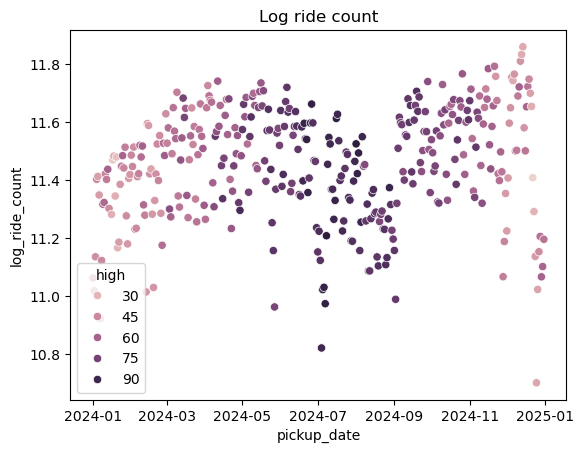

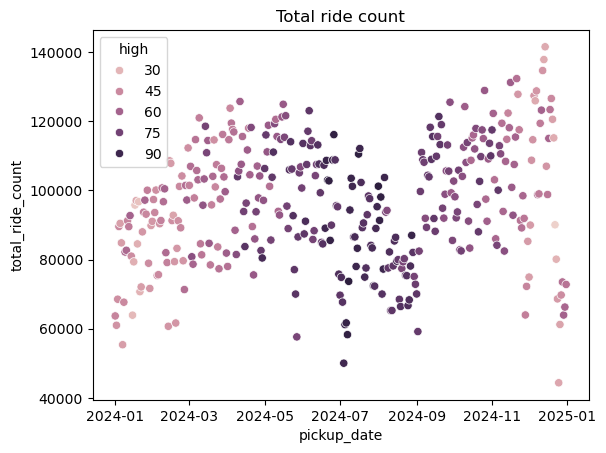

In [23]:
sns.scatterplot(data=daily, x='pickup_date', y='log_ride_count', hue='high')
plt.title("Log ride count")
plt.show()

sns.scatterplot(data=daily, x='pickup_date', y='total_ride_count', hue='high')
plt.title("Total ride count")
plt.show()

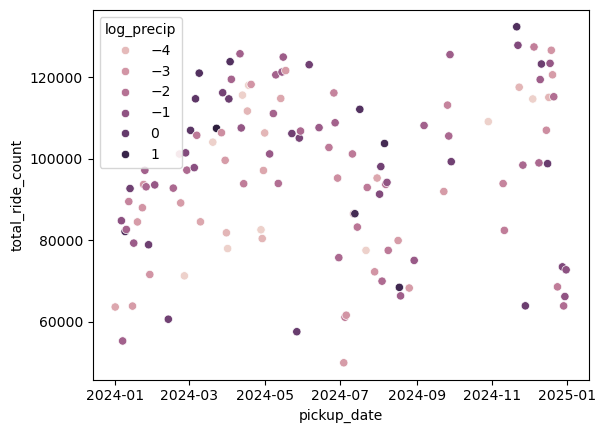

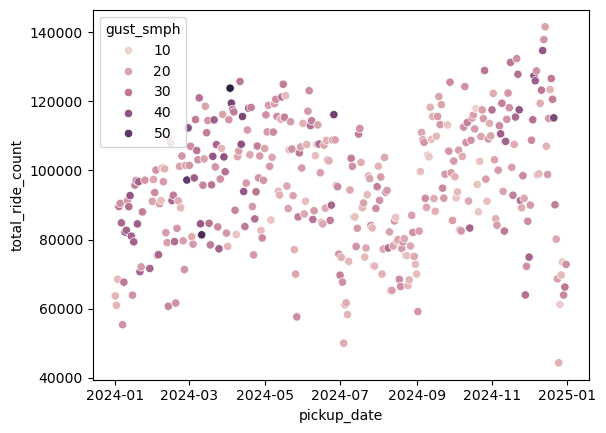

In [42]:
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='log_precip')
plt.show()

daily['log_gust'] = np.log(daily['gust_smph'].replace(0, np.nan))
sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='gust_smph')
plt.show()

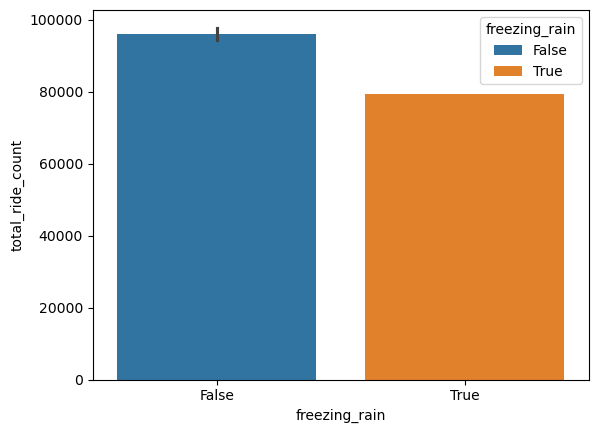

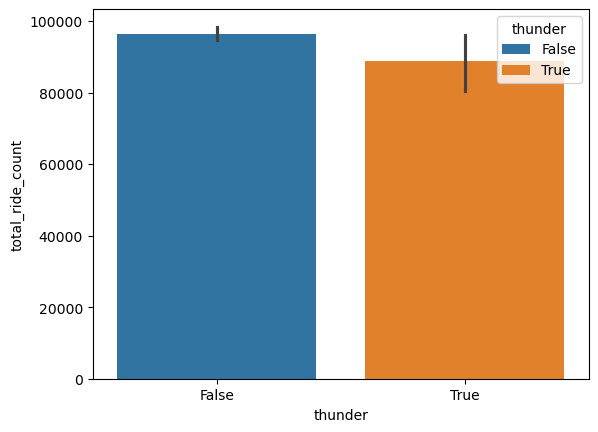

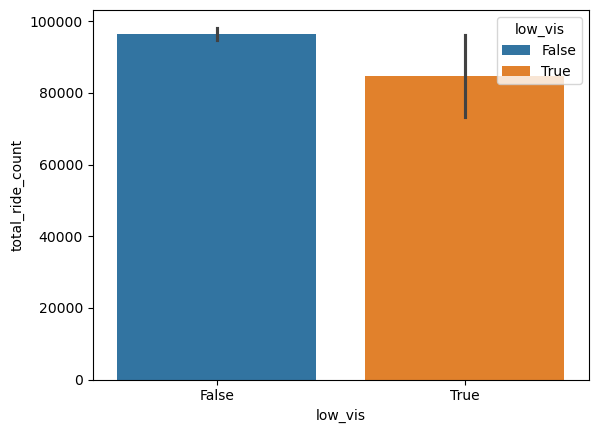

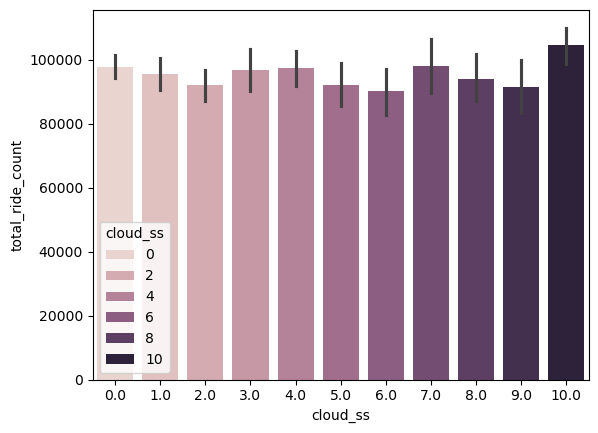

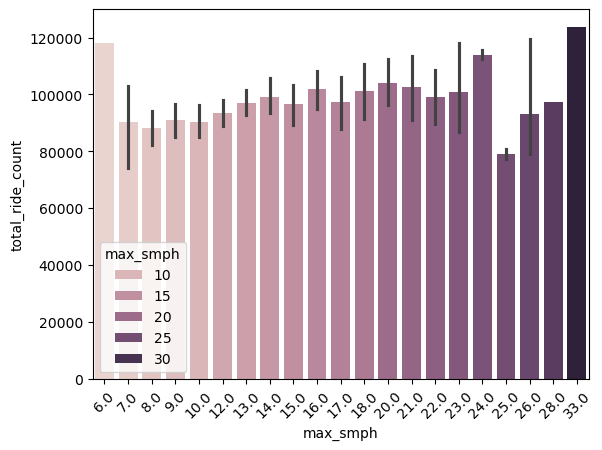

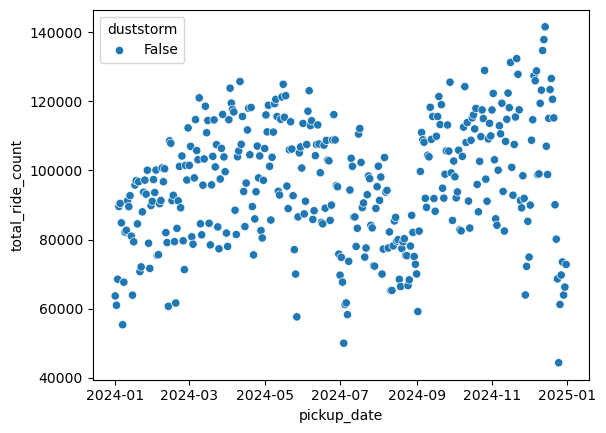

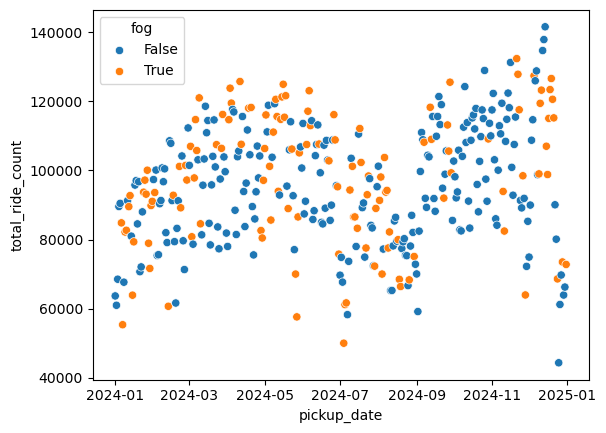

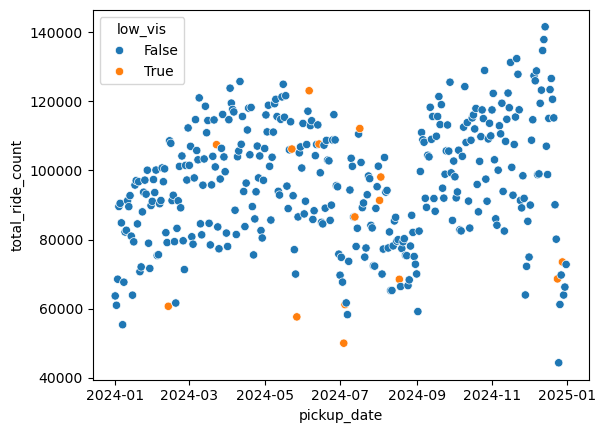

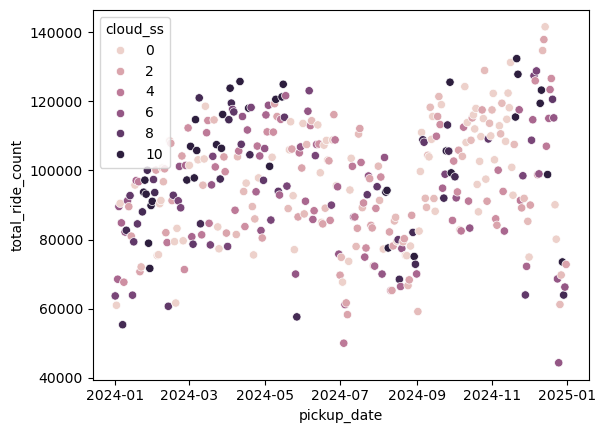

In [ ]:
#  #   Column         Non-Null Count  Dtype         
# ---  ------         --------------  -----         
#  0   high           366 non-null    int64         
#  1   low            366 non-null    int64         
#  2   avg_temp       366 non-null    float64       
#  3   dep_temp       366 non-null    float64       
#  4   precip         366 non-null    float64       
#  5   snow           366 non-null    float64       
#  6   max_smph       363 non-null    float64       
#  7   cloud_ss       366 non-null    float64       
#  8   gust_smph      360 non-null    float64       
#  9   date           366 non-null    datetime64[ns]
#  10  fog            366 non-null    bool          
#  11  low_vis        366 non-null    bool          
#  12  thunder        366 non-null    bool          
#  13  ice            366 non-null    bool          
#  14  hail           366 non-null    bool          
#  15  freezing_rain  366 non-null    bool          
#  16  duststorm      366 non-null    bool          
#  17  haze           366 non-null    bool          
sns.barplot(daily, x='freezing_rain', y='total_ride_count', hue='freezing_rain')
plt.show()

sns.barplot(daily, x='thunder', y='total_ride_count', hue='thunder')
plt.show()

sns.barplot(daily, x='low_vis', y='total_ride_count', hue='low_vis')
plt.show()

sns.barplot(daily, x='cloud_ss', y='total_ride_count', hue='cloud_ss')
plt.show()

sns.barplot(daily, x='max_smph', y='total_ride_count', hue='max_smph')
plt.xticks(rotation=45)
plt.show()

sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='fog')
plt.show()

sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='low_vis')
plt.show()

sns.scatterplot(daily, x='pickup_date', y='total_ride_count', hue='cloud_ss')
plt.show()